In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)

I0000 00:00:1787677022.561253  128381 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787677022.632974  128381 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787677024.231777  128381 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


### load the best model

In [2]:
ann_best = tf.keras.models.load_model(
    "../models/ann_early_stopping.keras"
)
rnn_best = tf.keras.models.load_model(
    "../models/rnn_batchnorm.keras"
)
lstm_best = tf.keras.models.load_model(
    "../models/lstm_sequence_300.keras"
)
gru_best = tf.keras.models.load_model(
    "../models/gru_rmsprop.keras"
)
bilstm_best = tf.keras.models.load_model(
    "../models/bilstm_rmsprop.keras"
)

E0000 00:00:1787677026.059901  128381 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787677026.060265  128459 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1787677026.072646  128381 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### loaded the datasets

In [3]:
import numpy as np
import tensorflow as tf

from scipy.sparse import load_npz

# =========================
# Load ANN TF-IDF data
# =========================

X_train_tfidf = load_npz("../models/X_train_tfidf.npz")
X_val_tfidf = load_npz("../models/X_val_tfidf.npz")
X_test_tfidf = load_npz("../models/X_test_tfidf.npz")


# =========================
# Load RNN/LSTM/GRU data
# =========================

X_train_padded = np.load("../models/X_train_padded.npy")
X_val_padded = np.load("../models/X_val_padded.npy")
X_test_padded = np.load("../models/X_test_padded.npy")


# =========================
# Load labels
# =========================

y_train = np.load("../models/y_train.npy")
y_val = np.load("../models/y_val.npy")
y_test = np.load("../models/y_test.npy")

# =========================
# Get sequence information
# =========================

sequence_length = X_train_padded.shape[1]
vocab_size = 20000

# =========================
# Check shapes
# =========================

print("ANN TF-IDF:")
print("X_train_tfidf:", X_train_tfidf.shape)
print("X_val_tfidf  :", X_val_tfidf.shape)
print("X_test_tfidf :", X_test_tfidf.shape)

print("\nPadded sequences:")
print("X_train_padded:", X_train_padded.shape)
print("X_val_padded  :", X_val_padded.shape)
print("X_test_padded :", X_test_padded.shape)

print("\nLabels:")
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

print("\nSequence length:", sequence_length)
print("Vocabulary size:", vocab_size)

ANN TF-IDF:
X_train_tfidf: (34705, 20000)
X_val_tfidf  : (7439, 20000)
X_test_tfidf : (7438, 20000)

Padded sequences:
X_train_padded: (34705, 200)
X_val_padded  : (7439, 200)
X_test_padded : (7438, 200)

Labels:
y_train: (34705,)
y_val  : (7439,)
y_test : (7438,)

Sequence length: 200
Vocabulary size: 20000


### evaluation metrics

In [4]:
def evaluate_model(model, model_name, x_test, y_test):

    # Prediction probability
    y_prob = model.predict(
        x_test,
        verbose=0
    ).ravel()

    # Convert probability to class
    y_pred = (y_prob >= 0.5).astype(int)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "=" * 50)
    print(model_name)
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Confusion Matrix": cm,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [5]:
phase6_results = []

### Predict model (ANN, RNN, LSTM, GRU, Bi-LSTM)

In [6]:
ann_result = evaluate_model(
    ann_best,
    "ANN - Best Model",
    X_test_tfidf,
    y_test
)

phase6_results.append(ann_result)


ANN - Best Model
Accuracy : 0.8943
Precision: 0.8926
Recall   : 0.8974
F1 Score : 0.8950
ROC-AUC  : 0.9605

Confusion Matrix:
[[3302  403]
 [ 383 3350]]


In [7]:
rnn_result = evaluate_model(
    rnn_best,
    "RNN - Best Model",
    X_test_padded,
    y_test
)
phase6_results.append(rnn_result)


RNN - Best Model
Accuracy : 0.5379
Precision: 0.5671
Recall   : 0.3351
F1 Score : 0.4213
ROC-AUC  : 0.5465

Confusion Matrix:
[[2750  955]
 [2482 1251]]


In [8]:
lstm_result = evaluate_model(
    lstm_best,
    "LSTM - Best Model",
    X_test_padded,
    y_test
)
phase6_results.append(lstm_result)


LSTM - Best Model
Accuracy : 0.8825
Precision: 0.8749
Recall   : 0.8937
F1 Score : 0.8842
ROC-AUC  : 0.9448

Confusion Matrix:
[[3228  477]
 [ 397 3336]]


In [9]:
gru_result = evaluate_model(
    gru_best,
    "GRU - Best Model",
    X_test_padded,
    y_test
)
phase6_results.append(gru_result)


GRU - Best Model
Accuracy : 0.8928
Precision: 0.9064
Recall   : 0.8770
F1 Score : 0.8915
ROC-AUC  : 0.9577

Confusion Matrix:
[[3367  338]
 [ 459 3274]]


In [10]:
bilstm_result = evaluate_model(
    bilstm_best,
    "Bi-LSTM - Best Model",
    X_test_padded,
    y_test
)
phase6_results.append(bilstm_result)


Bi-LSTM - Best Model
Accuracy : 0.8793
Precision: 0.8981
Recall   : 0.8567
F1 Score : 0.8769
ROC-AUC  : 0.9482

Confusion Matrix:
[[3342  363]
 [ 535 3198]]


### comparison table

In [11]:
phase6_results_df = pd.DataFrame([
    {
        "Model": result["Model"],
        "Accuracy": result["Accuracy"],
        "Precision": result["Precision"],
        "Recall": result["Recall"],
        "F1 Score": result["F1 Score"],
        "ROC-AUC": result["ROC-AUC"]
    }
    for result in phase6_results
])

phase6_results_df = phase6_results_df.round(4)

phase6_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANN - Best Model,0.8943,0.8926,0.8974,0.8950,0.9605
1,RNN - Best Model,0.5379,0.5671,0.3351,0.4213,0.5465
2,LSTM - Best Model,0.8825,0.8749,0.8937,0.8842,0.9448
3,GRU - Best Model,0.8928,0.9064,0.8770,0.8915,0.9577
4,Bi-LSTM - Best Model,0.8793,0.8981,0.8567,0.8769,0.9482


In [13]:
phase6_results_df.to_csv(
    "../models/phase6_results.csv",
    index=False
)

### Confusion Matrix

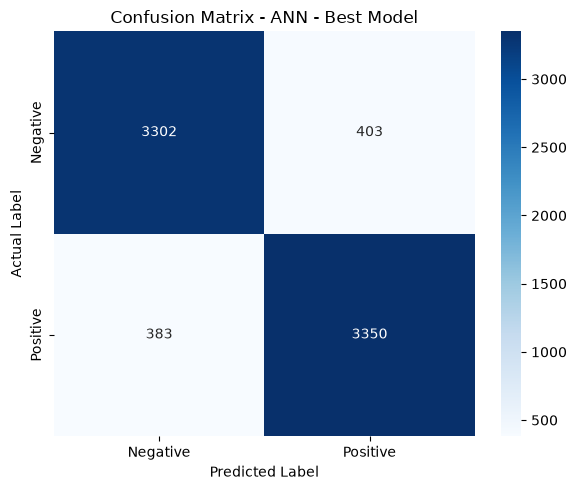

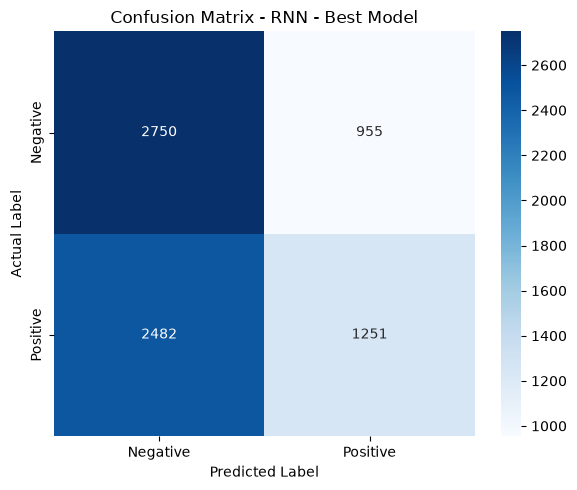

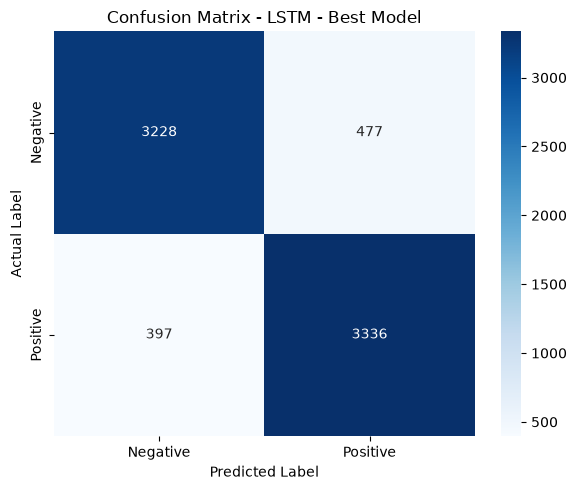

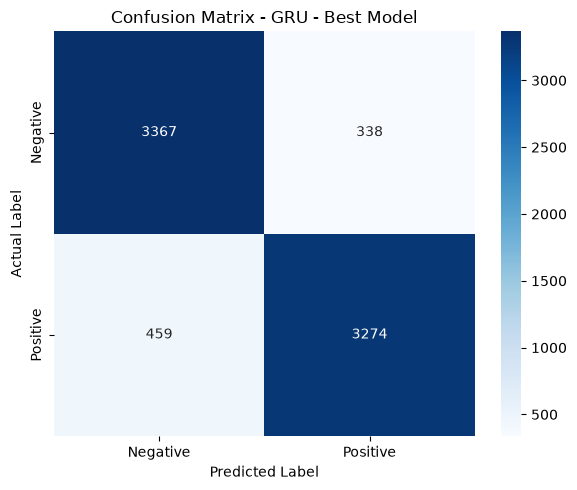

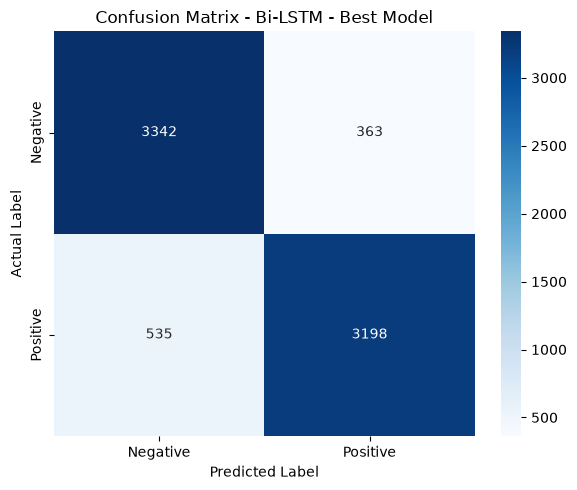

In [15]:
for result in phase6_results:

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        result["Confusion Matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    plt.title(
        f"Confusion Matrix - {result['Model']}"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()

### ROC-Curve

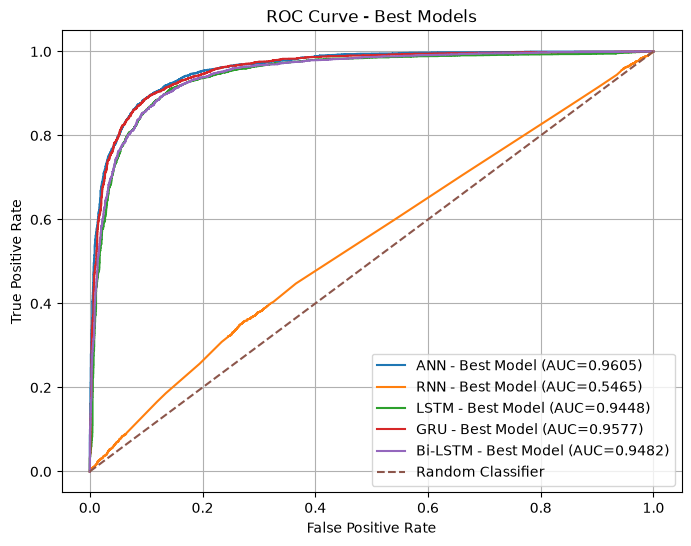

In [16]:
plt.figure(figsize=(8, 6))

for result in phase6_results:

    fpr, tpr, _ = roc_curve(
        y_test,
        result["y_prob"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{result['Model']} (AUC={result['ROC-AUC']:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Best Models")

plt.legend()
plt.grid()
plt.show()

### Precision - Re

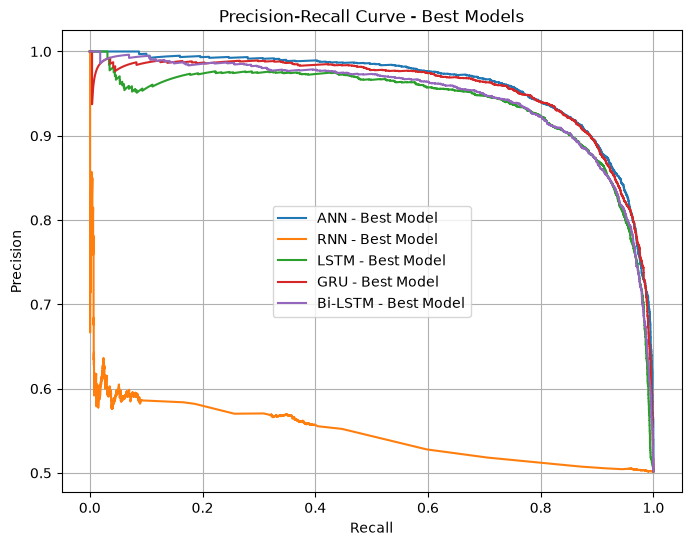

In [17]:
plt.figure(figsize=(8, 6))

for result in phase6_results:

    precision, recall, _ = precision_recall_curve(
        y_test,
        result["y_prob"]
    )

    plt.plot(
        recall,
        precision,
        label=result["Model"]
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - Best Models"
)

plt.legend()
plt.grid()
plt.show()

In [19]:
import pandas as pd

X_test_text = pd.read_pickle("../models/X_test_text.pkl")

print("Test reviews:", len(X_test_text))
print("Test labels:", len(y_test))

Test reviews: 7438
Test labels: 7438


In [20]:
misclassified_reviews = []

for result in phase6_results:

    y_pred = result["y_pred"]
    y_prob = result["y_prob"]

    incorrect_indices = np.where(
        y_pred != np.asarray(y_test)
    )[0]

    for index in incorrect_indices:

        actual_label = (
            y_test.iloc[index]
            if hasattr(y_test, "iloc")
            else y_test[index]
        )

        misclassified_reviews.append({
            "Model": result["Model"],
            "Review": X_test_text.iloc[index],
            "Actual": actual_label,
            "Predicted": y_pred[index],
            "Probability": y_prob[index]
        })

In [21]:
misclassified_df = pd.DataFrame(
    misclassified_reviews
)

misclassified_df.head(20)

,Model,Review,Actual,Predicted,Probability
0,ANN - Best Model,couple friends visited video shop years back o...,0,1,0.600692
1,ANN - Best Model,rating mini series approached well aware last ...,0,1,0.673375
2,ANN - Best Model,okay not sure counts spoiler ticked box anyway...,1,0,0.437480
3,ANN - Best Model,scooby doo undoubtedly one simple successful b...,0,1,0.814837
4,ANN - Best Model,may contain spoilers sadly lou costellos last ...,0,1,0.584837
5,ANN - Best Model,much looked forward movie good family movie ho...,0,1,0.805249
6,ANN - Best Model,today visited athenean cinema two kids years o...,0,1,0.801888
7,ANN - Best Model,short part four short cinema journal film rent...,1,0,0.094154
8,ANN - Best Model,hysterical thing movie according director diff...,0,1,0.740872
9,ANN - Best Model,people appreciate magical elements ros sets se...,1,0,0.409046


In [22]:
gru_misclassified = misclassified_df[
    misclassified_df["Model"] == "GRU - Best Model"
]

gru_misclassified.head(20)

,Model,Review,Actual,Predicted,Probability
5097,GRU - Best Model,rating mini series approached well aware last ...,0,1,0.805405
5098,GRU - Best Model,okay not sure counts spoiler ticked box anyway...,1,0,0.399154
5099,GRU - Best Model,much looked forward movie good family movie ho...,0,1,0.961010
5100,GRU - Best Model,today visited athenean cinema two kids years o...,0,1,0.749644
5101,GRU - Best Model,short part four short cinema journal film rent...,1,0,0.043164
5102,GRU - Best Model,people appreciate magical elements ros sets se...,1,0,0.267292
5103,GRU - Best Model,yoke undoubtedly controversial film stooges ye...,0,1,0.888579
5104,GRU - Best Model,zero day leads think even think two boys young...,1,0,0.322451
5105,GRU - Best Model,star rating saturday night friday night friday...,0,1,0.994458
5106,GRU - Best Model,hour running length crash charts emotional ang...,0,1,0.984193


In [23]:
gru_misclassified = misclassified_df[
    misclassified_df["Model"] == "RNN - Best Model"
]

gru_misclassified.head(20)

,Model,Review,Actual,Predicted,Probability
786,RNN - Best Model,rating mini series approached well aware last ...,0,1,0.780036
787,RNN - Best Model,okay not sure counts spoiler ticked box anyway...,1,0,0.370231
788,RNN - Best Model,terribly underrated matt dillon tom skerritt g...,1,0,0.370231
789,RNN - Best Model,scooby doo undoubtedly one simple successful b...,0,1,0.510450
790,RNN - Best Model,well got saw movie based rather high score goo...,0,1,0.558318
791,RNN - Best Model,alfred hitchcock made comedy mis marriage hear...,0,1,0.558318
792,RNN - Best Model,movie ageless would probably appeal children t...,1,0,0.370231
793,RNN - Best Model,tamara felt like another teen oriented knock k...,0,1,0.558318
794,RNN - Best Model,film different anything would seen honest chil...,1,0,0.370231
795,RNN - Best Model,even know begin one family worst line dialogue...,0,1,0.558318


In [24]:
gru_misclassified = misclassified_df[
    misclassified_df["Model"] == "LSTM - Best Model"
]

gru_misclassified.head(20)

,Model,Review,Actual,Predicted,Probability
4223,LSTM - Best Model,couple friends visited video shop years back o...,0,1,0.772578
4224,LSTM - Best Model,movie told eyes young teacher catholic school ...,0,1,0.695668
4225,LSTM - Best Model,much looked forward movie good family movie ho...,0,1,0.975832
4226,LSTM - Best Model,today visited athenean cinema two kids years o...,0,1,0.959558
4227,LSTM - Best Model,people appreciate magical elements ros sets se...,1,0,0.136886
4228,LSTM - Best Model,return lost world filmed back back version los...,1,0,0.245012
4229,LSTM - Best Model,yoke undoubtedly controversial film stooges ye...,0,1,0.894703
4230,LSTM - Best Model,times like truly wish avid reader clive barker...,0,1,0.891821
4231,LSTM - Best Model,star rating saturday night friday night friday...,0,1,0.810892
4232,LSTM - Best Model,hour running length crash charts emotional ang...,0,1,0.958602


In [26]:
gru_misclassified = misclassified_df[
    misclassified_df["Model"] == "Bi-LSTM - Best Model"
]

gru_misclassified.head(20)

,Model,Review,Actual,Predicted,Probability
5894,Bi-LSTM - Best Model,rating mini series approached well aware last ...,0,1,0.829992
5895,Bi-LSTM - Best Model,today visited athenean cinema two kids years o...,0,1,0.865505
5896,Bi-LSTM - Best Model,short part four short cinema journal film rent...,1,0,0.019214
5897,Bi-LSTM - Best Model,went movie expecting little action mixed stron...,0,1,0.895629
5898,Bi-LSTM - Best Model,return lost world filmed back back version los...,1,0,0.152561
5899,Bi-LSTM - Best Model,times like truly wish avid reader clive barker...,0,1,0.507123
5900,Bi-LSTM - Best Model,zero day leads think even think two boys young...,1,0,0.201387
5901,Bi-LSTM - Best Model,star rating saturday night friday night friday...,0,1,0.841790
5902,Bi-LSTM - Best Model,hour running length crash charts emotional ang...,0,1,0.953213
5903,Bi-LSTM - Best Model,st watched dir mick garris campy vampire like ...,0,1,0.634314
